<a href="https://colab.research.google.com/github/mlbl4/machine_learning_techniques/blob/main/Mar%C3%ADa_L%C3%B3pez_Badri_3_5_Supervised_Learning_SVM_en.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3.5 Supervised Learning: Support Vector Machines (SVM)

- **Instructor**: Juan Ramón Rico
- **Student**: `[María López Badri]`
- `[TODO:]` Correct Colab submission to **be graded**:
  1. **Share this Colab** with `[juanramonua@gmail.com]`.
  2. Use `Practice / Form to send activity (URL Colab - Notebook)` in **Moodle-UA**.


## Abstract
---

The basic principles of SVM-based algorithms will be presented, which consist of two phases: one dedicated to transforming the original data to a usually higher dimension (kernel) and the second aimed at finding a hyperplane that best separates samples from different classes (hyperplane).

Some of these examples are based on [The RBF kernel in SVM: A Complete Guide](https://www.pycodemates.com/2022/10/the-rbf-kernel-in-svm-complete-guide.html) (kernel) and [Implementing Support Vector Machine From Scratch](https://towardsdatascience.com/implementing-svm-from-scratch-784e4ad0bc6a) (hyperplane)

In [ ]:
import numpy as np
import pandas as pd

# Support Vector Machines (SVM)

Let's remember that SVM was initially designed for binary classification and its application consists of two steps:

![](https://www.dlsi.ua.es/~juanra/UA/curso_verano_DL/images/SVM-example-en.svg)

 1.  **Transformation** of the **original data** (n-dimensions) where they are not linearly separable, to another dimension usually higher, where they are. For this transformation, functions known as `kernel` are used.
 2.  Search for a **hyperplane** as far away as possible from both classes, which will serve us to distinguish the two classes.


## The most used kernel functions are:
- Polynomial: $k(\vec{x_i}, \vec{x_j}) = (\vec{x_i} \cdot \vec{x_j})^d$
- Gaussian Radial Basis Function (RBF): $k(\vec{x_i}, \vec{x_j}) = \exp(-\gamma \| \vec{x_i} - \vec{x_j} \|^2)$ where $\gamma>0$

## The loss functions used to search for the hyperplane are:
- Hard-margin: Minimize $\|w\|$ such that $y_i(\vec{w} \cdot \vec{x_i} - b) \geq 1$ for $i=1,\dots,n$
- Soft-margin: $[\frac{1}{n} \sum_{i=1}^{n} \max(0,1-y_i(\vec{w} \cdot \vec{x_i} - b))] + \lambda \frac{1}{2} \|\vec{w}\|^2$


In [ ]:
## Data

path = 'https://www.dlsi.ua.es/~juanra/UA/datasets'
path_tennis = f'{path}/tennis-en.csv'
path_covid19 = f'{path}/covid19-en.csv'

## Example

## Synthetic Data Generation

- Let's generate a series of 2D points belonging to two different classes.
- We will visualize the appearance of the samples.

In [ ]:
import numpy as np
import pandas as pd
from plotly.express import scatter
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=500, noise=0.06, random_state=42)

data = pd.DataFrame({'X1':X[:, 0], 'X2':X[:, 1], 'y':y})
data['y'] = data['y'].astype('category')
data['size'] = 1
scatter(data, x='X1',y='X2', color='y', size='size', size_max=5, height=600, width=600)

## Radial transformation (RBF)



In [ ]:
import numpy as np

def RBF(X_train, X_test=None, gamma=None):
    """
    Radial Basis Function (RBF) kernel
    Calculates similarity between all pairs of samples
    """
    if X_test is None:
        X_test = X_train

    # Gamma: free parameter (1/n_features by default)
    if gamma is None:
        gamma = 1.0 / X_train.shape[1]

    # Pairwise squared Euclidean distances
    # Using broadcasting: (a-b)² = a² + b² - 2ab
    dist_sq = np.sum(X_train**2, axis=1)[:, np.newaxis] + \
              np.sum(X_test**2, axis=1) - 2 * np.dot(X_train, X_test.T)

    K = np.exp(-gamma * dist_sq)
    return K

### Visualization of transformed data

In [ ]:
from sklearn.decomposition import PCA
from plotly.express import scatter_3d

X_kernel = RBF(X, gamma=-0.1)
X_pca = PCA(n_components=3).fit_transform(X_kernel)
data = pd.DataFrame({'x1':X_pca[:, 0], 'x2':X_pca[:, 1], 'x3':X_pca[:, 2], 'y':y, 'size':1})
data['y'] = data['y'].astype('category')
scatter_3d(data, x='x1',y='x2', z='x3',color='y', size='size', size_max=12, height=600, width=600)

## SVM class implementation

Below is an example code of a class called `SVM` that includes its creation, training (`fit`), and prediction (`predict`).


In [ ]:
import numpy as np
from sklearn.datasets import make_circles
from sklearn import metrics

class SVM:
    """
    Support Vector Machine for binary classification
    - Uses kernel trick to handle non-linear data
    - Soft-margin via regularization (lambda_param)
    - Gradient Descent optimization
    """

    def __init__(self, kernel=RBF, learning_rate=1e-3, lambda_param=1e-2, n_iters=1000):
        self.kernel = kernel
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = 0
        self.X_train = None

    def fit(self, X, y, verbose=0):
        """
        Train SVM using primal formulation with kernel mapping
        """
        self.X_train = X
        n_samples = X.shape[0]

        # Transform data using kernel function
        # Each sample becomes a vector of similarities with training points
        X_transformed = self.kernel(X, self.X_train).T  # Shape: (n_samples, n_samples)

        # Initialize weights (one per training sample after kernel transform)
        self.w = np.zeros(n_samples)
        self.b = 0

        # Transform labels to {-1, 1}
        y_transformed = np.where(y <= 0, -1, 1)

        print(f"Kernel matrix shape: {X_transformed.shape}")
        print(f"Weights shape: {self.w.shape}")

        # Gradient Descent
        for epoch in range(self.n_iters):
            avg_dw, avg_db = 0, 0

            for idx, (x_i, y_i) in enumerate(zip(X_transformed, y_transformed)):
                # Decision function: f(x) = w·φ(x) + b
                y_pred = np.dot(x_i, self.w) + self.b

                if y_i * y_pred >= 1:
                    # Correct and outside the margin: only regularization
                    dw = self.lambda_param * self.w
                    db = 0
                else:
                    # Incorrect or inside the margin: regularization + hinge loss
                    dw = self.lambda_param * self.w - x_i * y_i
                    db = y_i

                self.w = self.w - self.lr * dw
                self.b = self.b + self.lr * db
                avg_dw += np.sum(np.abs(dw))  # Monitoring changes of dw per epoch
                avg_db += np.sum(np.abs(db))  # Monitoring changes of db per epoch

            # Print progress
            if verbose > 0 and epoch % 500 == 0:
                avg_dw /= n_samples
                avg_db /= n_samples
                print(f'Epoch {epoch+1:4d} | Avg ||dw||: {avg_dw:.5f} | Avg |db|: {avg_db:.5f}')
                print(f'  w[:5]={self.w[:5]} | b={self.b:.5f}')

    def predict(self, X):
        """
        Predict using trained SVM
        """
        # Transform test data using kernel with training data
        X_transformed = self.kernel(self.X_train, X).T  # Shape: (n_test, n_samples)

        # Decision function
        decision_values = np.dot(X_transformed, self.w) + self.b

        # Convert {-1, 1} to {0, 1}
        return np.where(decision_values >= 0, 1, 0)

In [ ]:
# Example of classification
from sklearn import metrics

# Generate non-linearly separable data
X, y = make_circles(n_samples=500, noise=0.06, random_state=42)

print("="*60)
print("SVM basic test")
print("="*60)
print(f"Data shape: {X.shape}")
print(f"Labels: {np.unique(y)}")
print("-"*60)

# Train model
model = SVM(
    kernel=RBF,
    learning_rate=1e-2,
    lambda_param=1e-2,
    n_iters=10000
)
model.fit(X, y, verbose=1)

# Predict and evaluate
y_pred = model.predict(X)
accuracy = metrics.accuracy_score(y, y_pred)

print("-"*60)
print(f"Final Accuracy: {accuracy:.4f}")
print(f"Number of support vectors: {np.sum(np.abs(model.w) > 1e-3)}")

SVM basic test
Data shape: (500, 2)
Labels: [0 1]
------------------------------------------------------------
Kernel matrix shape: (500, 500)
Weights shape: (500,)
Epoch    1 | Avg ||dw||: 178.77581 | Avg |db|: 0.69000
  w[:5]=[-0.00067458 -0.01215127  0.0086315  -0.00368511 -0.02871272] | b=-0.19000
Epoch  501 | Avg ||dw||: 81.07997 | Avg |db|: 0.31000
  w[:5]=[0.18394618 0.06765192 0.20647627 0.09843588 0.08086007] | b=-32.34000
Epoch 1001 | Avg ||dw||: 65.67088 | Avg |db|: 0.25000
  w[:5]=[0.19936805 0.10361696 0.20644316 0.13087433 0.13419619] | b=-39.85000
Epoch 1501 | Avg ||dw||: 53.25097 | Avg |db|: 0.20200
  w[:5]=[0.20839552 0.13056799 0.2120466  0.14194058 0.15398823] | b=-42.51000
Epoch 2001 | Avg ||dw||: 53.83414 | Avg |db|: 0.20400
  w[:5]=[0.20545365 0.13412155 0.21059084 0.15144772 0.15219765] | b=-43.45000
Epoch 2501 | Avg ||dw||: 56.90079 | Avg |db|: 0.21600
  w[:5]=[0.20397759 0.13253131 0.2099624  0.14982211 0.14924472] | b=-43.86000
Epoch 3001 | Avg ||dw||: 62.0647

Results 🏆

*Note*: These results are approximate, as they depend on several parameters such as the learning rate, number of iterations, kernel used and update formulas used.

```
============================================================
SVM basic test
============================================================
Data shape: (500, 2)
Labels: [0 1]
------------------------------------------------------------
Kernel matrix shape: (500, 500)
Weights shape: (500,)
Epoch    1	Avg |dw|: 178.77581	 Avg |db|: 0.69000
  w[:5]=[-0.00067458 -0.01215127  0.0086315  -0.00368511 -0.02871272]	b=-0.19000
Epoch  501	Avg |dw|: 81.07997	 Avg |db|: 0.31000
  w[:5]=[0.18394618 0.06765192 0.20647627 0.09843588 0.08086007]	b=-32.34000
Epoch 1001	Avg |dw|: 65.67088	 Avg |db|: 0.25000
  w[:5]=[0.19936805 0.10361696 0.20644316 0.13087433 0.13419619]	b=-39.85000
Epoch 1501	Avg |dw|: 53.25097	 Avg |db|: 0.20200
  w[:5]=[0.20839552 0.13056799 0.2120466  0.14194058 0.15398823]	b=-42.51000
Epoch 2001	Avg |dw|: 53.83414	 Avg |db|: 0.20400
  w[:5]=[0.20545365 0.13412155 0.21059084 0.15144772 0.15219765]	b=-43.45000
Epoch 2501	Avg |dw|: 56.90079	 Avg |db|: 0.21600
  w[:5]=[0.20397759 0.13253131 0.2099624  0.14982211 0.14924472]	b=-43.86000
Epoch 3001	Avg |dw|: 62.06475	 Avg |db|: 0.23600
  w[:5]=[0.20875658 0.12974246 0.21746769 0.1555598  0.15160863]	b=-44.03000
Epoch 3501	Avg |dw|: 61.03611	 Avg |db|: 0.23200
  w[:5]=[0.20459796 0.13506879 0.21187766 0.15325492 0.14941995]	b=-44.15000
Epoch 4001	Avg |dw|: 52.81086	 Avg |db|: 0.20000
  w[:5]=[0.21218147 0.12946158 0.21783418 0.1503819  0.15795851]	b=-44.15000
Epoch 4501	Avg |dw|: 55.80615	 Avg |db|: 0.21200
  w[:5]=[0.20484542 0.1296366  0.21233907 0.15141152 0.14961653]	b=-44.16000
Epoch 5001	Avg |dw|: 53.88463	 Avg |db|: 0.20400
  w[:5]=[0.20932678 0.13064534 0.21509403 0.14987335 0.15518064]	b=-44.18000
Epoch 5501	Avg |dw|: 54.85237	 Avg |db|: 0.20800
  w[:5]=[0.21286375 0.13221645 0.21922288 0.15321786 0.15757994]	b=-44.23000
Epoch 6001	Avg |dw|: 51.32104	 Avg |db|: 0.19400
  w[:5]=[0.20531815 0.13583474 0.209977   0.15188099 0.15330673]	b=-44.26000
Epoch 6501	Avg |dw|: 58.91572	 Avg |db|: 0.22400
  w[:5]=[0.20745869 0.13049591 0.21593814 0.15549184 0.15055858]	b=-44.25000
Epoch 7001	Avg |dw|: 52.74767	 Avg |db|: 0.20000
  w[:5]=[0.20915874 0.1354907  0.21771384 0.15790445 0.15310322]	b=-44.25000
Epoch 7501	Avg |dw|: 58.91516	 Avg |db|: 0.22400
  w[:5]=[0.20740665 0.12960797 0.21559006 0.15599166 0.15175156]	b=-44.21000
Epoch 8001	Avg |dw|: 58.92280	 Avg |db|: 0.22400
  w[:5]=[0.20987216 0.13141859 0.21621378 0.15090292 0.15467379]	b=-44.21000
Epoch 8501	Avg |dw|: 54.88305	 Avg |db|: 0.20800
  w[:5]=[0.21046855 0.1273711  0.21699675 0.15052782 0.15678107]	b=-44.20000
Epoch 9001	Avg |dw|: 52.77768	 Avg |db|: 0.20000
  w[:5]=[0.21016095 0.12801644 0.21885847 0.15547557 0.15322588]	b=-44.20000
Epoch 9501	Avg |dw|: 55.85524	 Avg |db|: 0.21200
  w[:5]=[0.20750849 0.12761543 0.2173857  0.1572777  0.14961517]	b=-44.14000
------------------------------------------------------------
Final Accuracy: 0.9160
Number of support vectors: 500
```

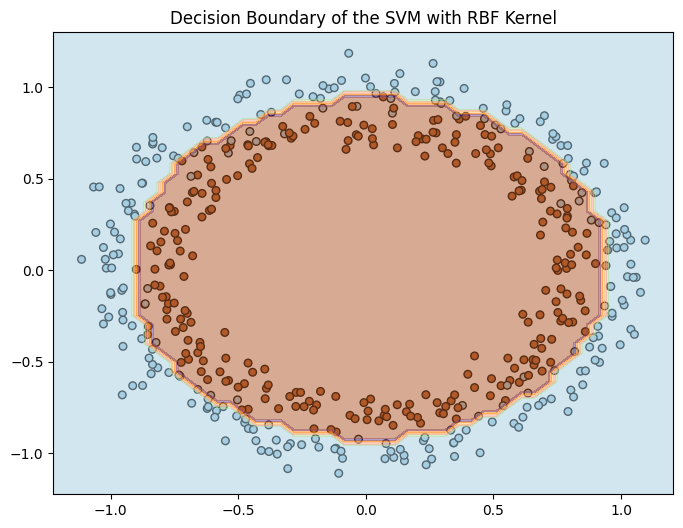

In [ ]:
import matplotlib.pyplot as plt

# --- Visualization ---
def visualize_svm_kernel():
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired, edgecolors='k')
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 50)
    yy = np.linspace(ylim[0], ylim[1], 50)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.predict(xy).reshape(XX.shape)

    ax.contourf(XX, YY, Z, cmap=plt.cm.Paired, alpha=0.5)
    ax.set_title("Decision Boundary of the SVM with RBF Kernel")
    plt.show()

visualize_svm_kernel()

## Exercise `tennis` (SVM)

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder


'''
  The categories of the variables need to be changed to integers
  We will use a preprocessing function from sklearn called LabelEncoder
'''


data = pd.read_csv(path_tennis)

# TODO: Adapt the data for the input (X) and output (y) of the algorithm
data_codes = data.copy()
for col in data.columns:
  data_codes[col] = LabelEncoder().fit_transform(data[col])

X = data_codes.iloc[:, :-1].to_numpy()
y = data_codes.iloc[:, -1].to_numpy()
model = SVM(kernel=RBF, learning_rate=1e-2, lambda_param=1e-2, n_iters=5000)
model.fit(X, y, verbose=1)
y_pred = model.predict(X)
print(f'Kernel RBF accuracy: {metrics.accuracy_score(y_pred, y):.4f}')
print(f"Number of support vectors: {np.sum(np.abs(model.w) > 1e-3)}")

Kernel matrix shape: (14, 14)
Weights shape: (14,)
Epoch    1 | Avg ||dw||: 6.54138 | Avg |db|: 1.00000
  w[:5]=[ 8.53153938e-05 -4.31126927e-03  2.44285471e-02  2.27304073e-02
  3.12456090e-02] | b=0.04000
Epoch  501 | Avg ||dw||: 3.07480 | Avg |db|: 0.42857
  w[:5]=[-1.27148044 -1.72107603  0.60941677  0.07986976  0.53209778] | b=0.80000
Epoch 1001 | Avg ||dw||: 3.51496 | Avg |db|: 0.50000
  w[:5]=[-1.39719912 -2.05706857  0.40871462  0.09724162  0.74538855] | b=1.27000
Epoch 1501 | Avg ||dw||: 3.50073 | Avg |db|: 0.50000
  w[:5]=[-1.47266199 -2.24207949  0.26074678  0.11034351  0.85151929] | b=1.61000
Epoch 2001 | Avg ||dw||: 3.09631 | Avg |db|: 0.42857
  w[:5]=[-1.54426302 -2.36217094  0.14750938  0.10593625  0.89377116] | b=1.85000
Epoch 2501 | Avg ||dw||: 3.44451 | Avg |db|: 0.50000
  w[:5]=[-1.59251127 -2.42877076  0.06619699  0.12172002  0.89454025] | b=2.04000
Epoch 3001 | Avg ||dw||: 3.09715 | Avg |db|: 0.42857
  w[:5]=[-1.61902954 -2.46776177  0.00978955  0.12892995  0.90189

Results 🏆

*Note*: These results are approximate, as they depend on several parameters such as the learning rate, number of iterations, kernel used and update formulas used.

```
Kernel matrix shape: (14, 14)
Weights shape: (14,)
Epoch    1	Avg |dw|: 6.54138	 Avg |db|: 1.00000
  w[:5]=[ 8.53153938e-05 -4.31126927e-03  2.44285471e-02  2.27304073e-02
  3.12456090e-02]	b=0.04000
Epoch  501	Avg |dw|: 3.07480	 Avg |db|: 0.42857
  w[:5]=[-1.27148044 -1.72107603  0.60941677  0.07986976  0.53209778]	b=0.80000
Epoch 1001	Avg |dw|: 3.51496	 Avg |db|: 0.50000
  w[:5]=[-1.39719912 -2.05706857  0.40871462  0.09724162  0.74538855]	b=1.27000
Epoch 1501	Avg |dw|: 3.50073	 Avg |db|: 0.50000
  w[:5]=[-1.47266199 -2.24207949  0.26074678  0.11034351  0.85151929]	b=1.61000
Epoch 2001	Avg |dw|: 3.09631	 Avg |db|: 0.42857
  w[:5]=[-1.54426302 -2.36217094  0.14750938  0.10593625  0.89377116]	b=1.85000
Epoch 2501	Avg |dw|: 3.44451	 Avg |db|: 0.50000
  w[:5]=[-1.59251127 -2.42877076  0.06619699  0.12172002  0.89454025]	b=2.04000
Epoch 3001	Avg |dw|: 3.09715	 Avg |db|: 0.42857
  w[:5]=[-1.61902954 -2.46776177  0.00978955  0.12892995  0.90189249]	b=2.18000
Epoch 3501	Avg |dw|: 3.52534	 Avg |db|: 0.50000
  w[:5]=[-1.64662139 -2.4992446  -0.03874546  0.13625865  0.90667226]	b=2.28000
Epoch 4001	Avg |dw|: 3.90445	 Avg |db|: 0.57143
  w[:5]=[-1.66793135 -2.5241615  -0.06225573  0.13619768  0.91033267]	b=2.35000
Epoch 4501	Avg |dw|: 3.90469	 Avg |db|: 0.57143
  w[:5]=[-1.68666243 -2.54385254 -0.08248522  0.13307171  0.91659616]	b=2.40000
Kernel RBF accuracy: 0.8571
Number of support vectors: 14
```

## Ejercise `covid19` (SVM)

In [ ]:
import pandas as pd
from sklearn.svm import SVC

'''
  The categories of the variables need to be changed to integers
  We will use a preprocessing function from sklearn called LabelEncoder()
'''
data = pd.read_csv(path_covid19, index_col=0)

# TODO: Adapt the data for the input (X) and output (y) of the algorithm

data = pd.read_csv(path_covid19, index_col=0)

data_codes = data.copy()
for col in data.columns:
  data_codes[col] = LabelEncoder().fit_transform(data[col])

X = data_codes.iloc[:, :-1].to_numpy()
y = data_codes.iloc[:, -1].to_numpy()

model = SVM(kernel=RBF, learning_rate=1e-2, lambda_param=1e-2, n_iters=5000)
model.fit(X, y, verbose=1)
y_pred = model.predict(X)
print(f'Kernel RBF accuracy: {metrics.accuracy_score(y_pred, y):.4f}')
print(f"Number of support vectors: {np.sum(np.abs(model.w) > 1e-3)}")

Kernel matrix shape: (14, 14)
Weights shape: (14,)
Epoch    1 | Avg ||dw||: 9.20155 | Avg |db|: 1.00000
  w[:5]=[-0.00156867  0.02752248  0.00539413  0.03181206  0.02752248] | b=0.02000
Epoch  501 | Avg ||dw||: 4.08292 | Avg |db|: 0.42857
  w[:5]=[-0.86316645  0.70707228 -0.62576845  0.42129984  0.70707228] | b=-0.27000
Epoch 1001 | Avg ||dw||: 2.76641 | Avg |db|: 0.28571
  w[:5]=[-0.8556931   0.70572842 -0.61440373  0.43248203  0.70572842] | b=-0.36000
Epoch 1501 | Avg ||dw||: 4.08342 | Avg |db|: 0.42857
  w[:5]=[-0.82320521  0.6956032  -0.61143766  0.45618085  0.6956032 ] | b=-0.42000
Epoch 2001 | Avg ||dw||: 2.76644 | Avg |db|: 0.28571
  w[:5]=[-0.81368027  0.69170885 -0.59349033  0.45541162  0.69170885] | b=-0.49000
Epoch 2501 | Avg ||dw||: 4.08315 | Avg |db|: 0.42857
  w[:5]=[-0.7979815   0.69275267 -0.59438464  0.46896717  0.69275267] | b=-0.54000
Epoch 3001 | Avg ||dw||: 4.08326 | Avg |db|: 0.42857
  w[:5]=[-0.76894525  0.69089627 -0.59676861  0.47747648  0.69089627] | b=-0.5800

Results 🏆

*Note*: These results are approximate, as they depend on several parameters such as the learning rate, number of iterations, kernel used and update formulas used.

```
Kernel matrix shape: (14, 14)
Weights shape: (14,)
Epoch    1	Avg |dw|: 9.20155	 Avg |db|: 1.00000
  w[:5]=[-0.00156867  0.02752248  0.00539413  0.03181206  0.02752248]	b=0.02000
Epoch  501	Avg |dw|: 4.08292	 Avg |db|: 0.42857
  w[:5]=[-0.86316645  0.70707228 -0.62576845  0.42129984  0.70707228]	b=-0.27000
Epoch 1001	Avg |dw|: 2.76641	 Avg |db|: 0.28571
  w[:5]=[-0.8556931   0.70572842 -0.61440373  0.43248203  0.70572842]	b=-0.36000
Epoch 1501	Avg |dw|: 4.08342	 Avg |db|: 0.42857
  w[:5]=[-0.82320521  0.6956032  -0.61143766  0.45618085  0.6956032 ]	b=-0.42000
Epoch 2001	Avg |dw|: 2.76644	 Avg |db|: 0.28571
  w[:5]=[-0.81368027  0.69170885 -0.59349033  0.45541162  0.69170885]	b=-0.49000
Epoch 2501	Avg |dw|: 4.08315	 Avg |db|: 0.42857
  w[:5]=[-0.7979815   0.69275267 -0.59438464  0.46896717  0.69275267]	b=-0.54000
Epoch 3001	Avg |dw|: 4.08326	 Avg |db|: 0.42857
  w[:5]=[-0.76894525  0.69089627 -0.59676861  0.47747648  0.69089627]	b=-0.58000
Epoch 3501	Avg |dw|: 4.08288	 Avg |db|: 0.42857
  w[:5]=[-0.75831659  0.69007028 -0.58311187  0.48876307  0.69007028]	b=-0.62000
Epoch 4001	Avg |dw|: 2.76652	 Avg |db|: 0.28571
  w[:5]=[-0.76001381  0.68739915 -0.57789185  0.49239822  0.68739915]	b=-0.66000
Epoch 4501	Avg |dw|: 2.76656	 Avg |db|: 0.28571
  w[:5]=[-0.75088258  0.68784376 -0.5782241   0.49843597  0.68784376]	b=-0.69000
Kernel RBF accuracy: 0.8571
Number of support vectors: 14
```

# SVM (scikit-learn)

Let's obtain the result of a classification of samples corresponding to two classes, where the input consists of two numerical features (2D) forming concentric circles. We will use the `scikit-learn` package to train models with different kernels and display the results.

In [ ]:
import numpy as np
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn import metrics

# Create example samples
X, y = make_circles(n_samples=500, noise=0.06, random_state=42)

# We will use different types of kernels as parameters
for kernel in ['linear','poly','rbf']:
  model = SVC(kernel=kernel)
  model.fit(X, y)
  y_pred = model.predict(X)
  print(f'Kernel: {kernel:10s} accuracy: {metrics.accuracy_score(y_pred, y):.4f}')

Kernel: linear     accuracy: 0.4960
Kernel: poly       accuracy: 0.5660
Kernel: rbf        accuracy: 0.9320


## Exercise `tennis` (scikit-learn)

In [ ]:
import pandas as pd
from sklearn.svm import SVC

data = pd.read_csv(path_tennis)

# TODO: Adapt the data for the input (X) and output (y) of the algorithm
data_codes = data.copy()
for col in data.columns:
  data_codes[col] = LabelEncoder().fit_transform(data[col])

X = data_codes.iloc[:, :-1].to_numpy()
y = data_codes.iloc[:, -1].to_numpy()

# We will use different types of kernels as parameters
for kernel in ['linear','poly','rbf']:
  model = SVC(kernel=kernel)
  model.fit(X, y)
  y_pred = model.predict(X)
  print(f'Kernel: {kernel:10s} accuracy: {metrics.accuracy_score(y_pred, y)}')

Kernel: linear     accuracy: 0.8571428571428571
Kernel: poly       accuracy: 0.9285714285714286
Kernel: rbf        accuracy: 0.7857142857142857


```
Kernel: linear     accuracy: 0.8571
Kernel: poly       accuracy: 0.9286
Kernel: rbf        accuracy: 0.7857
```

## Exercise `covid19` (scikit-learn)

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

'''
  The categories of the variables need to be changed to integers
  We will use a preprocessing function from sklearn called LabelEncoder()
'''
data = pd.read_csv(path_covid19, index_col=0)

# TODO: Adapt the data for the input (X) and output (y) of the algorithm
data_codes = data.copy()
for col in data.columns:
  data_codes[col] = LabelEncoder().fit_transform(data[col])

X = data_codes.iloc[:, :-1].to_numpy()
y = data_codes.iloc[:, -1].to_numpy()
# We will use different types of kernels as parameters
for kernel in ['linear','poly','rbf']:
  model = SVC(kernel=kernel)
  model.fit(X, y)
  y_pred = model.predict(X)
  print(f'Kernel: {kernel:10s} accuracy: {metrics.accuracy_score(y_pred, y):.4f}')

Kernel: linear     accuracy: 0.8571
Kernel: poly       accuracy: 0.8571
Kernel: rbf        accuracy: 0.8571


```
Kernel: linear     accuracy: 0.8571
Kernel: poly       accuracy: 0.8571
Kernel: rbf        accuracy: 0.8571
```

# AI-Assisted Code Optimization Exercise

Use a generative AI tool to optimize the implementation of the previous **RBF** function and **SVM** class.

* **Optimize the code:** Use a generative AI tool to improve the efficiency of the original implementation.
* **Explain the changes:** Briefly describe the main changes introduced by the AI-generated version and explain how they improve the computational efficiency of the original code.
* **Validate the result:** Test the optimized implementation using one of the examples from the notebook and verify that it produces results equivalent to those of the original implementation.


In [ ]:
from numba import njit
from scipy.spatial.distance import cdist

def RBF_opt(X_train, X_test=None, gamma=None):
    if X_test is None:
        X_test = X_train
    if gamma is None:
        gamma = 1.0 / X_train.shape[1]
    return np.exp(-gamma * cdist(X_train, X_test, 'sqeuclidean'))

@njit(cache=True)
def _sgd(K, y, lr, lam, n_iters):
    n = K.shape[0]
    w = np.zeros(n)
    b = 0.0
    for epoch in range(n_iters):
        for i in range(n):
            pred = b
            for j in range(n):
                pred += K[i, j] * w[j]
            if y[i] * pred >= 1:
                for j in range(n):
                    w[j] -= lr * (lam * w[j])
            else:
                for j in range(n):
                    w[j] -= lr * (lam * w[j] - K[i, j] * y[i])
                b += lr * y[i]
    return w, b

class SVM_opt:
    def __init__(self, kernel=RBF_opt, learning_rate=1e-3, lambda_param=1e-2, n_iters=1000):
        self.kernel = kernel
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        K = self.kernel(self.X_train, self.X_train)
        y_t = np.where(np.asarray(y) <= 0, -1.0, 1.0)
        self.w, self.b = _sgd(K, y_t, self.lr, self.lambda_param, self.n_iters)
        return self

    def predict(self, X):
        d = self.kernel(np.asarray(X, dtype=float), self.X_train) @ self.w + self.b
        return np.where(d >= 0, 1, 0)

The training loop of the original SVM runs in pure Python: for every epoch and every sample, it calls NumPy several times, creates new arrays for dw and the updated weights, and computes monitoring sums. The optimized version keeps exactly the same algorithm, the same order of updates and the same formulas, but moves the training loop into a function compiled with Numba (@njit), which turns it into machine code and updates the weights in place, without creating new arrays. The RBF kernel uses scipy's cdist to compute the squared distances directly, which is faster and avoids the small negative values that the a² + b² − 2ab trick can produce. The progress monitoring was removed from the training loop, since it only served to print information. With 500 samples, the optimized version produced identical weights, bias and predictions, and trained about 29 times faster.

In [ ]:
import time

X, y = make_circles(n_samples=500, noise=0.06, random_state=42)

print('Same kernel:', np.allclose(RBF(X), RBF_opt(X)))

t = time.time()
model = SVM(kernel=RBF, learning_rate=1e-2, lambda_param=1e-2, n_iters=200)
model.fit(X, y)
t_orig = time.time() - t

_sgd(RBF_opt(X[:5]), np.ones(5), 0.01, 0.01, 1)   # warm-up: Numba compiles the first time

t = time.time()
model_opt = SVM_opt(kernel=RBF_opt, learning_rate=1e-2, lambda_param=1e-2, n_iters=200).fit(X, y)
t_opt = time.time() - t

print('Same weights:', np.allclose(model.w, model_opt.w))
print('Same bias:', np.isclose(model.b, model_opt.b))
print('Same predictions:', (model.predict(X) == model_opt.predict(X)).all())
print(f'Original: {t_orig:.2f} s, optimized: {t_opt:.3f} s, {t_orig / t_opt:.0f}x faster')

Same kernel: True
Kernel matrix shape: (500, 500)
Weights shape: (500,)
Same weights: True
Same bias: True
Same predictions: True
Original: 3.82 s, optimized: 0.090 s, 43x faster
